# Figure 5 timing-study tutorial

이 노트북은 Cho 2023 Figure 5 스타일의 질문, 즉 **치료 시점(early vs late)** 과 **coverage(50% vs 100%)** 가 파라미터 추정과 식별성에 어떤 차이를 만드는지 설명합니다.

핵심 목표는 세 가지입니다.

1. Figure 5형 문제를 synthetic data로 어떻게 구성하는지 이해하기
2. early/late timing arm을 같이 fit할 때 목적함수가 어떻게 바뀌는지 이해하기
3. 어떤 실험 설계가 더 잘 식별되는지 비교하기


## 1. Figure 5형 synthetic 질문

Figure 4가 주로 **고정된 치료 시점에서 volume curve를 맞추는 문제**라면, Figure 5형 질문은 **치료를 시작하는 시점이 달라질 때 결과가 어떻게 달라지는가**에 더 가깝습니다.

여기서는 이를 다음 두 방식으로 synthetic하게 흉내냅니다.

- early treatment: `treatment_day = 10`
- late treatment: `treatment_day = 15`

coverage는 두 arm을 같이 둡니다.

- partial irradiation: 50%
- full irradiation: 100%


## 2. fit할 파라미터와 목적함수

이 튜토리얼에서도 기본적으로 아래 파라미터를 추정합니다.

$$
\theta = (\psi,\ \omega,\ \kappa,\ T_0)
$$

Figure 5형 mixed design에서는 arm 집합을 $a \in \mathcal{A}$ 로 두고, 각 arm마다 dose, coverage, treatment day가 달라질 수 있습니다.

관측 residual은

$$
r_{a,i}(\theta) = \log(V_{a,i}^{pred}(\theta)+\epsilon) - \log(V_{a,i}^{obs}+\epsilon)
$$

이고, weak prior residual은

$$
r_j^{prior}(\theta) = \frac{\log(\theta_j)-\log(\theta_{j,base})}{\sigma_{prior}}
$$

입니다. 최종 목적함수는

$$
J(\theta) = \sum_{a \in \mathcal{A}} \sum_i r_{a,i}(\theta)^2 + \sum_j \left(r_j^{prior}(\theta)\right)^2
$$

입니다. 즉, **여러 timing/coverage arm을 동시에 설명하는 파라미터**를 찾습니다.


## 3. 방법론

파라미터 탐색은 Figure 4 튜토리얼과 동일하게 2단계입니다.

$$
\text{Differential Evolution} \;\rightarrow\; \text{Least Squares}
$$

- Differential Evolution: 전역 탐색으로 좋은 파라미터 영역을 찾음
- Least Squares: 그 영역에서 residual norm을 더 정밀하게 줄임

여기서 중요한 차이는, Figure 5형 문제에서는 **하나의 곡선**이 아니라 **timing이 다른 여러 arm**을 함께 맞춘다는 점입니다.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / 'radiology_modeling').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root =', repo_root)


repo_root = /drive2/2026/Radiology


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from radiology_modeling.fit import DEFAULT_FIT_SPECS
from radiology_modeling.model import ModelParameters
from radiology_modeling.observability_study import (
    DEFAULT_START_VOLUME_SCENARIOS,
    fit_observability_dataset,
    generate_observability_dataset,
    run_start_volume_grid,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)


## 4. Figure 5형 synthetic dataset 만들기

여기서는 먼저 `startvol_mixed_4arm_d10` 시나리오를 씁니다.

이 시나리오는 다음 4개 arm을 동시에 포함합니다.

- 10 Gy @ 50%, treatment day 10
- 10 Gy @ 50%, treatment day 15
- 10 Gy @ 100%, treatment day 10
- 10 Gy @ 100%, treatment day 15


In [3]:
true_params = ModelParameters(
    rho=0.5,
    psi=300.0,
    omega=0.135,
    k=1.1,
    gamma=0.0,
    initial_volume=0.03,
    treatment_day=10,
    dose_gy=10.0,
)
base_params = ModelParameters()
scenario = next(s for s in DEFAULT_START_VOLUME_SCENARIOS if s.name == 'startvol_mixed_4arm_d10')
dataset = generate_observability_dataset(true_params, scenario, seed=31)

pd.DataFrame([
    {
        'measurement': m.name,
        'observable': m.observable,
        'dose_gy': m.dose_gy,
        'coverage': m.coverage,
        'treatment_day': m.treatment_day,
        'n_points': len(m.relative_days),
    }
    for m in dataset.measurements
])


,measurement,observable,dose_gy,coverage,treatment_day,n_points
0,total_volume_dose_10.0_coverage_0.50_tx_10,total_volume,10.0,0.5,10,11
1,total_volume_dose_10.0_coverage_0.50_tx_15,total_volume,10.0,0.5,15,11
2,total_volume_dose_10.0_coverage_1.00_tx_10,total_volume,10.0,1.0,10,11
3,total_volume_dose_10.0_coverage_1.00_tx_15,total_volume,10.0,1.0,15,11


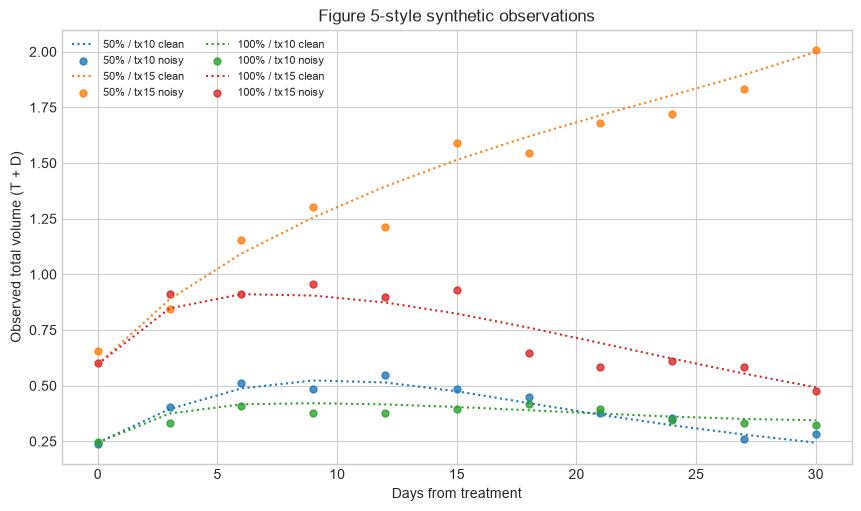

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.0), constrained_layout=True)
for measurement in dataset.measurements:
    label = f"{int(round(100*measurement.coverage))}% / tx{measurement.treatment_day}"
    ax.plot(measurement.relative_days, measurement.clean_values, linewidth=1.5, linestyle=':', label=f'{label} clean')
    ax.scatter(measurement.relative_days, measurement.observed_values, s=25, alpha=0.8, label=f'{label} noisy')
ax.set_title('Figure 5-style synthetic observations')
ax.set_xlabel('Days from treatment')
ax.set_ylabel('Observed total volume (T + D)')
ax.legend(fontsize=8, ncol=2)
plt.show()


## 5. mixed timing design에 대한 fitting

이제 위 4개 arm을 **동시에** 맞춥니다. 즉, early/late와 partial/full을 모두 설명하는 하나의 $\hat{\theta}$를 찾습니다.


In [5]:
fit_result = fit_observability_dataset(
    dataset,
    base_params=base_params,
    fit_specs=DEFAULT_FIT_SPECS,
    seed=41,
)

pd.DataFrame([
    {
        'parameter': spec.name,
        'true': fit_result.true_values[spec.name],
        'fitted': fit_result.fitted_values[spec.name],
        'rel_error_pct': 100.0 * (fit_result.fitted_values[spec.name] - fit_result.true_values[spec.name]) / fit_result.true_values[spec.name],
    }
    for spec in DEFAULT_FIT_SPECS
])


,parameter,true,fitted,rel_error_pct
0,psi,300.000,322.9684,7.6561
1,omega,0.135,0.1212,-10.2297
2,k,1.100,1.3019,18.3568
3,initial_volume,0.030,0.0340,13.2211


In [6]:
print(f'local_cost    = {fit_result.local_cost:.6f}')
print(f'residual_norm = {fit_result.residual_norm:.6f}')


local_cost    = 12.380676
residual_norm = 3.518618


## 6. Figure 5형 design comparison

이제 더 중요한 부분입니다. Figure 5형 질문에서는 **어떤 arm 구성이 더 식별성이 좋은가**가 중요합니다.

이미 구현된 start-volume grid 실험은 아래 4개 시나리오를 비교합니다.

- `startvol_partial_pair_d10`
- `startvol_full_pair_d10`
- `startvol_mixed_4arm_d10`
- `startvol_mixed_4arm_plus_immune`

`artifacts/start_volume_grid` 결과가 없으면 여기서 생성하고, 있으면 바로 읽습니다.


In [7]:
output_dir = repo_root / 'artifacts' / 'start_volume_grid'
ranking_path = output_dir / 'scenario_ranking.csv'
posterior_path = output_dir / 'posterior_widths.csv'

if not ranking_path.exists() or not posterior_path.exists():
    run_start_volume_grid(str(output_dir))

ranking_df = pd.read_csv(ranking_path)
posterior_df = pd.read_csv(posterior_path)
ranking_df


,scenario,mean_rel_width90
0,startvol_mixed_4arm_plus_immune,0.8854
1,startvol_mixed_4arm_d10,0.9020
2,startvol_partial_pair_d10,1.0327
3,startvol_full_pair_d10,1.0699


In [8]:
summary_table = (
    posterior_df
    .pivot(index='parameter', columns='scenario', values='rel_width90')
    .round(3)
)
summary_table


scenario,startvol_full_pair_d10,startvol_mixed_4arm_d10,startvol_mixed_4arm_plus_immune,startvol_partial_pair_d10
parameter,,,,
initial_volume,1.189,0.926,0.692,1.132
k,1.097,1.023,0.981,1.104
omega,0.789,0.673,0.697,0.650
psi,1.205,0.986,1.171,1.244


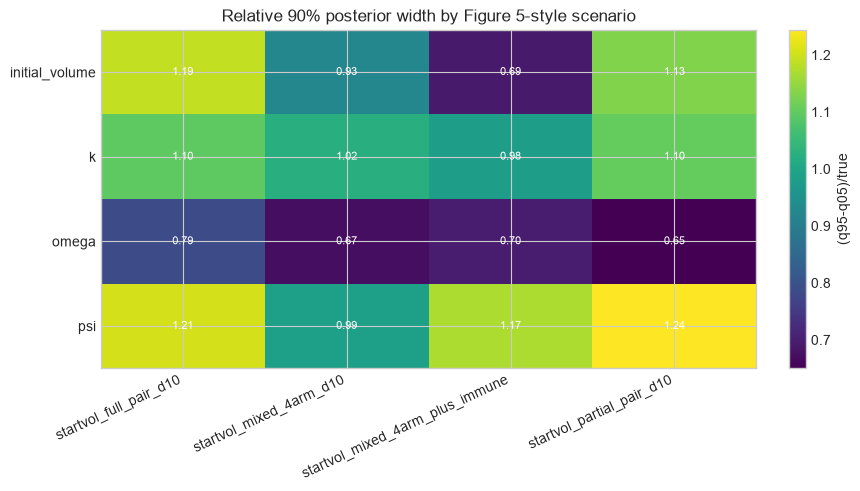

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
image = ax.imshow(summary_table.values, aspect='auto', cmap='viridis')
ax.set_xticks(np.arange(summary_table.shape[1]), labels=summary_table.columns, rotation=25, ha='right')
ax.set_yticks(np.arange(summary_table.shape[0]), labels=summary_table.index)
ax.set_title('Relative 90% posterior width by Figure 5-style scenario')
for i in range(summary_table.shape[0]):
    for j in range(summary_table.shape[1]):
        ax.text(j, i, f'{summary_table.values[i, j]:.2f}', ha='center', va='center', color='white', fontsize=8)
fig.colorbar(image, ax=ax, label='(q95-q05)/true')
plt.show()


## 8. 요약

Figure 5형 synthetic study에서 중요한 건 단순히 곡선을 하나 더 맞추는 것이 아닙니다. 핵심은:

1. 치료 시점 변화가 파라미터 추정에 추가 정보를 준다
2. partial/full을 같이 보는 것이 single-arm보다 낫다
3. immune readout이 있으면 식별성이 더 좋아진다

즉 Figure 5형 질문의 실험 설계 메시지는

$$
\text{timing variation} + \text{coverage variation} + \text{immune readout}
$$

가 가장 강하다는 것입니다.


## 8. 요약

Figure 5형 synthetic study에서 중요한 건 단순히 곡선을 하나 더 맞추는 것이 아닙니다. 핵심은:

1. 치료 시점 변화가 파라미터 추정에 추가 정보를 준다
2. partial/full을 같이 보는 것이 single-arm보다 낫다
3. immune readout이 있으면 식별성이 더 좋아진다

즉 Figure 5형 질문의 실험 설계 메시지는

$$
	ext{timing variation} + 	ext{coverage variation} + 	ext{immune readout}
$$

가 가장 강하다는 것입니다.
